# Cella 1 - Importazioni:

In [1]:
# Importazione delle librerie necessarie
import os
import re
import pandas as pd
import numpy as np
from decimal import Decimal
import sys
sys.path.append('..')
from script.connessioni import get_mysql_connection

# Configurazione pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\venv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.10) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


# Cella 2 - Carica dati da raw_data in DataFrame:

In [2]:
# Connessione al database
conn = get_mysql_connection()

# Carica tutti i dati da raw_data in un DataFrame
query = "SELECT * FROM raw_data"
df_raw = pd.read_sql(query, conn)

conn.close()

print(f"Dataset caricato: {df_raw.shape[0]} righe, {df_raw.shape[1]} colonne")
df_raw.head()

Dataset caricato: 170 righe, 40 colonne


C:\Users\Utente\AppData\Local\Temp\ipykernel_11636\2358833697.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_raw = pd.read_sql(query, conn)


,id,timestamp,email_indirizzo,email_app,consenso,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15,Item_16,Item_17,Item_18,Item_19,Item_20,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30
0,1,2026-01-24 13:59:40,None,None,Accetto,Entrambi,24,Femmina,Nord Italia,5,4.0,5.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,5.0,1.0,1.0,2.0,2.0,4.0,5.0,5.0,Durante gli esami e se devo interagire con gli...
1,2,2026-01-24 14:51:07,None,None,Accetto,Di studio,26,Femmina,Nord Italia,7 anni,4.0,5.0,3.0,4.0,3.0,4.0,3.0,2.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,5.0,4.0,4.0,4.0,2.0,4.0,1.0,3.0,3.0,5.0,2.0,2.0,2.0,4.0,Durante gli esami
2,3,2026-01-24 14:51:23,None,None,Accetto,Di lavoro,26,Maschio,Nord Italia,5 anni,3.0,4.0,3.0,4.0,4.0,4.0,5.0,3.0,2.0,1.0,4.0,4.0,2.0,2.0,2.0,4.0,2.0,4.0,5.0,5.0,3.0,5.0,1.0,1.0,4.0,2.0,5.0,4.0,5.0,Interazione con persone (clienti)
3,4,2026-01-24 14:54:35,None,None,Accetto,Entrambi,26,Femmina,Nord Italia,5,2.0,4.0,3.0,5.0,5.0,3.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,5.0,3.0,5.0,3.0,2.0,5.0,3.0,3.0,2.0,3.0,2.0,1.0,3.0,L’esame
4,5,2026-01-24 15:00:36,None,None,Accetto,Di studio,22,Femmina,Nord Italia,2,3.0,2.0,3.0,4.0,4.0,3.0,2.0,2.0,3.0,1.0,4.0,3.0,3.0,3.0,2.0,4.0,3.0,3.0,2.0,1.0,2.0,2.0,3.0,2.0,4.0,3.0,3.0,2.0,4.0,"Durante il tirocinio, quando devo mettere effe..."


# Cella 3 - Esplora il dataset:

In [3]:
# Creazione di una copia per la pulizia dei dati
df_clean = df_raw.copy()  

# Informazioni sul dataset
print("Informazioni sul dataset:\n")
df_clean.info()

print("\nValori nulli per colonna:")
print(df_clean.isnull().sum())

#NOTA: DA SISTEMARE DATATYPE

Informazioni sul dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               170 non-null    int64         
 1   timestamp        170 non-null    datetime64[ns]
 2   email_indirizzo  2 non-null      object        
 3   email_app        13 non-null     object        
 4   consenso         170 non-null    object        
 5   contesto         168 non-null    object        
 6   età              168 non-null    object        
 7   genere           168 non-null    object        
 8   area_geo         168 non-null    object        
 9   anni_esperienza  168 non-null    object        
 10  Item_1           168 non-null    float64       
 11  Item_2           168 non-null    float64       
 12  Item_3           168 non-null    float64       
 13  Item_4           168 non-null    float64       
 14  Item_5         

In [4]:
righe_prima = len(df_clean)

# Filtra solo righe dove consenso != "Accetto" 
for x in df_clean.index:
    if df_clean.loc[x, 'consenso'] != 'Accetto':
        df_clean = df_clean.drop(x)

righe_dopo = len(df_clean)
righe_eliminate_consenso = righe_prima - righe_dopo

# Elimina la colonna consenso
df_clean = df_clean.drop(columns=['consenso'])

print(f"Righe con consenso 'non accetto' eliminate: {righe_eliminate_consenso}")
print(f"Colonna 'consenso' eliminata")


Righe con consenso 'non accetto' eliminate: 2
Colonna 'consenso' eliminata


In [5]:
for col in df_clean.columns:
    for row in df_clean.index:
        if col == 'Item_30':
            df_clean['Item_30'] = df_clean['Item_30'].astype(str)
        elif 'Item' in col and pd.notna(df_clean.loc[row, col]):
            df_clean.loc[row, col] = int(df_clean.loc[row, col])
            
df_clean['contesto'] = df_clean['contesto'].astype(str, errors='ignore')

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 168 entries, 0 to 169
Data columns (total 39 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               168 non-null    int64         
 1   timestamp        168 non-null    datetime64[ns]
 2   email_indirizzo  2 non-null      object        
 3   email_app        13 non-null     object        
 4   contesto         168 non-null    object        
 5   età              168 non-null    object        
 6   genere           168 non-null    object        
 7   area_geo         168 non-null    object        
 8   anni_esperienza  168 non-null    object        
 9   Item_1           168 non-null    float64       
 10  Item_2           168 non-null    float64       
 11  Item_3           168 non-null    float64       
 12  Item_4           168 non-null    float64       
 13  Item_5           168 non-null    float64       
 14  Item_6           160 non-null    float64       

# Cella 4 - Funzione pulizia età:

In [6]:
# Funzione per pulire e convertire l'età
def pulisci_eta(eta_raw):
    """
    Converte l'età da testo a intero.
    FILTRO: Solo età tra 19 e 30 anni
    """
    if pd.isna(eta_raw) or eta_raw == '':
        return None
    
    eta_raw = eta_raw.lower()
    
    for i in ['anni', 'anno']:
        eta_raw = eta_raw.replace(i, '')
        eta_int = int(eta_raw)
        if eta_int < 19 or eta_int > 30:
            return None
        return eta_int
    
    return None
# CONTROLLARE DATATYPE ETA
# Applica la funzione al DataFrame
df_clean['età_pulita'] = df_clean['età'].apply(pulisci_eta)

print("Test pulizia età:\n")
print(df_clean[['età', 'età_pulita']].head(10))

# VERIFICARE QUANTE RIGHE SONO STATE ESCLUSE
print(f"\nRighe da escludere (età fuori range 19-30): {df_clean['età_pulita'].isna().sum()}")

Test pulizia età:

  età  età_pulita
0  24        24.0
1  26        26.0
2  26        26.0
3  26        26.0
4  22        22.0
5  26        26.0
6  26        26.0
7  24        24.0
8  20        20.0
9  30        30.0

Righe da escludere (età fuori range 19-30): 17


# Cella 5 - Funzione pulizia anni esperienza:

In [7]:
def pulisci_anni_esperienza(exp_raw):
    """Converte anni esperienza in formato anni.mesi"""
    if pd.isna(exp_raw) or exp_raw == '':
        return None
    
    exp_str = str(exp_raw).lower().replace(',', '.')
    
    totale_anni = 0
    totale_mesi = 0
    
    # Caso 1: "X anni"
    anni_match = re.findall(r'(\d+)\s*ann[oi]', exp_str)
    for a in anni_match:
        totale_anni += int(a)
    
    # Caso 2: "Y mesi"
    mesi_match = re.findall(r'(\d+(?:\.\d+)?)\s*mes[ei]', exp_str)
    for m in mesi_match:
        mesi_val = float(m)
        if mesi_val < 1:
            totale_mesi += int(mesi_val * 10)  # 0.7 mesi → 7 mesi (interpreta come 0.X anni)
        else:
            totale_mesi += int(mesi_val)
    
    # Caso 3: "mezzo"
    if 'mezzo' in exp_str or 'mezza' in exp_str:
        totale_mesi += 6
    
    # Caso 4: Numeri decimali (se non ha trovato "anni" o "mesi")
    if totale_anni == 0 and totale_mesi == 0:
        # Trova TUTTI i numeri decimali e sommali
        decimali = re.findall(r'\d+\.\d+', exp_str)
        
        for dec in decimali:
            val = float(dec)
            anni_parte = int(val)
            mesi_parte = int(round((val - anni_parte) * 10))  # Parte decimale × 10
            
            totale_anni += anni_parte
            totale_mesi += mesi_parte
    
    # Caso 5: Solo interi
    if totale_anni == 0 and totale_mesi == 0:
        numeri = re.findall(r'\b(\d+)\b', exp_str)
        if numeri:
            totale_anni = int(numeri[0])
    
    # Normalizza
    if totale_mesi >= 12:
        totale_anni += totale_mesi // 12
        totale_mesi = totale_mesi % 12
    
    # Formato finale
    return float(f"{totale_anni}.{totale_mesi:02d}")  # :02d garantisce sempre 2 cifre

# Test
print("Test:\n")
tests = ['1,1', '0,8', '9,5', '0,7 mesi', '2.5 lavoro di cui 0.5 studio']
for t in tests:
    print(f"'{t}' → {pulisci_anni_esperienza(t)}")

# Applica al DataFrame
df_clean['anni_esperienza_pulita'] = df_clean['anni_esperienza'].apply(pulisci_anni_esperienza)

print("\nTest su dati reali:\n")
print(df_clean[['anni_esperienza', 'anni_esperienza_pulita']].head(40))

Test:

'1,1' → 1.01
'0,8' → 0.08
'9,5' → 9.05
'0,7 mesi' → 0.07
'2.5 lavoro di cui 0.5 studio' → 2.1

Test su dati reali:

                                anni_esperienza  anni_esperienza_pulita
0                                             5                    5.00
1                                        7 anni                    7.00
2                                        5 anni                    5.00
3                                             5                    5.00
4                                             2                    2.00
5                                             8                    8.00
6                                        5 anni                    5.00
7                                             0                    0.00
8                                        2 Anni                    2.00
9                                            11                   11.00
10                                       5 anni                    5.00
11           

# Cella 6 - Pulizia incoerenze contesto:

In [8]:
# Funzione per pulire incoerenze tra contesto e risposte
def pulisci_incoerenze_items(row):
    """
    Pulisce incoerenze tra contesto e Items.
    - Se "Di studio" → Item_16-20 (lavoro) = NULL
    - Se "Di lavoro" → Item_11-15 (studio) = NULL
    - Se "Entrambi" → tutto OK
    """
    contesto = str(row['contesto']).lower()
    
    # Se contesto è "Di studio" → cancella Item_16-20
    if 'studio' in contesto and 'entrambi' not in contesto and 'lavoro' not in contesto:
        for i in range(16, 21):  # Item_16 a Item_20
            row[f'Item_{i}'] = None
    
    # Se contesto è "Di lavoro" → cancella Item_11-15
    elif 'lavoro' in contesto and 'entrambi' not in contesto and 'studio' not in contesto:
        for i in range(11, 16):  # Item_11 a Item_15
            row[f'Item_{i}'] = None
    
    return row

# Analisi PRIMA della pulizia
print("PRIMA della pulizia incoerenze:\n")
for idx, row in df_clean.head(10).iterrows():
    contesto = row['contesto']
    studio_count = sum(1 for i in range(11, 16) if pd.notna(row[f'Item_{i}']))
    lavoro_count = sum(1 for i in range(16, 21) if pd.notna(row[f'Item_{i}']))
    print(f"ID {row['id']} | Contesto: {contesto:15s} | Studio: {studio_count}/5 | Lavoro: {lavoro_count}/5")

# Applica la pulizia
df_clean = df_clean.apply(pulisci_incoerenze_items, axis=1)

print("\nDOPO la pulizia incoerenze:\n")
for idx, row in df_clean.head(10).iterrows():
    contesto = row['contesto']
    studio_count = sum(1 for i in range(11, 16) if pd.notna(row[f'Item_{i}']))
    lavoro_count = sum(1 for i in range(16, 21) if pd.notna(row[f'Item_{i}']))
    print(f"ID {row['id']} | Contesto: {contesto:15s} | Studio: {studio_count}/5 | Lavoro: {lavoro_count}/5")

PRIMA della pulizia incoerenze:

ID 1 | Contesto: Entrambi        | Studio: 5/5 | Lavoro: 5/5
ID 2 | Contesto: Di studio       | Studio: 5/5 | Lavoro: 5/5
ID 3 | Contesto: Di lavoro       | Studio: 5/5 | Lavoro: 5/5
ID 4 | Contesto: Entrambi        | Studio: 5/5 | Lavoro: 5/5
ID 5 | Contesto: Di studio       | Studio: 5/5 | Lavoro: 5/5
ID 6 | Contesto: Di lavoro       | Studio: 5/5 | Lavoro: 5/5
ID 7 | Contesto: Di lavoro       | Studio: 5/5 | Lavoro: 5/5
ID 8 | Contesto: Disoccupazione  | Studio: 5/5 | Lavoro: 5/5
ID 9 | Contesto: Di lavoro       | Studio: 5/5 | Lavoro: 5/5
ID 10 | Contesto: Entrambi        | Studio: 5/5 | Lavoro: 5/5

DOPO la pulizia incoerenze:

ID 1 | Contesto: Entrambi        | Studio: 5/5 | Lavoro: 5/5
ID 2 | Contesto: Di studio       | Studio: 5/5 | Lavoro: 0/5
ID 3 | Contesto: Di lavoro       | Studio: 0/5 | Lavoro: 5/5
ID 4 | Contesto: Entrambi        | Studio: 5/5 | Lavoro: 5/5
ID 5 | Contesto: Di studio       | Studio: 5/5 | Lavoro: 0/5
ID 6 | Contesto: Di l

In [9]:
df_raw.head(20)

,id,timestamp,email_indirizzo,email_app,consenso,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15,Item_16,Item_17,Item_18,Item_19,Item_20,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30
0,1,2026-01-24 13:59:40,None,None,Accetto,Entrambi,24,Femmina,Nord Italia,5,4.0,5.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,5.0,1.0,1.0,2.0,2.0,4.0,5.0,5.0,Durante gli esami e se devo interagire con gli...
1,2,2026-01-24 14:51:07,None,None,Accetto,Di studio,26,Femmina,Nord Italia,7 anni,4.0,5.0,3.0,4.0,3.0,4.0,3.0,2.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,5.0,4.0,4.0,4.0,2.0,4.0,1.0,3.0,3.0,5.0,2.0,2.0,2.0,4.0,Durante gli esami
2,3,2026-01-24 14:51:23,None,None,Accetto,Di lavoro,26,Maschio,Nord Italia,5 anni,3.0,4.0,3.0,4.0,4.0,4.0,5.0,3.0,2.0,1.0,4.0,4.0,2.0,2.0,2.0,4.0,2.0,4.0,5.0,5.0,3.0,5.0,1.0,1.0,4.0,2.0,5.0,4.0,5.0,Interazione con persone (clienti)
3,4,2026-01-24 14:54:35,None,None,Accetto,Entrambi,26,Femmina,Nord Italia,5,2.0,4.0,3.0,5.0,5.0,3.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,5.0,3.0,5.0,3.0,2.0,5.0,3.0,3.0,2.0,3.0,2.0,1.0,3.0,L’esame
4,5,2026-01-24 15:00:36,None,None,Accetto,Di studio,22,Femmina,Nord Italia,2,3.0,2.0,3.0,4.0,4.0,3.0,2.0,2.0,3.0,1.0,4.0,3.0,3.0,3.0,2.0,4.0,3.0,3.0,2.0,1.0,2.0,2.0,3.0,2.0,4.0,3.0,3.0,2.0,4.0,"Durante il tirocinio, quando devo mettere effe..."
5,6,2026-01-24 15:30:50,None,None,Accetto,Di lavoro,26,Maschio,Nord Italia,8,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,3.0,2.0,2.0,2.0,1.0,2.0,3.0,2.0,2.0,2.0,1.0,2.0,4.0,4.0,5.0,5.0,2.0,1.0,3.0,Durate una attivtà di aggiornamento sistema al...
6,7,2026-01-24 17:26:08,None,None,Accetto,Di lavoro,26,Femmina,Nord Italia,5 anni,3.0,2.0,1.0,3.0,4.0,2.0,1.0,1.0,1.0,1.0,3.0,2.0,2.0,1.0,1.0,2.0,3.0,4.0,3.0,2.0,2.0,1.0,4.0,3.0,2.0,4.0,1.0,1.0,2.0,Situazioni in cui devo affrontare colloqui che...
7,8,2026-01-24 19:31:04,None,None,Accetto,Disoccupazione,24,Maschio,Centro Italia,0,4.0,4.0,3.0,5.0,4.0,3.0,2.0,3.0,4.0,2.0,4.0,3.0,4.0,4.0,5.0,4.0,5.0,5.0,4.0,4.0,3.0,3.0,1.0,2.0,2.0,1.0,4.0,4.0,5.0,None
8,9,2026-01-24 19:45:55,None,None,Accetto,Di lavoro,20,Femmina,Sud Italia e Isole,2 Anni,5.0,5.0,5.0,5.0,5.0,4.0,3.0,4.0,4.0,1.0,3.0,3.0,5.0,5.0,3.0,4.0,3.0,3.0,4.0,3.0,5.0,3.0,1.0,1.0,5.0,4.0,1.0,1.0,5.0,Si sempre
9,10,2026-01-24 20:45:41,None,None,Accetto,Entrambi,30,Maschio,Nord Italia,11,2.0,1.0,2.0,5.0,5.0,2.0,4.0,1.0,3.0,5.0,2.0,3.0,4.0,5.0,3.0,2.0,2.0,2.0,5.0,2.0,3.0,4.0,3.0,4.0,3.0,5.0,5.0,4.0,5.0,La parte esecutiva dei progetti da fare a casa...


# Cella 7 - Filtra per età e crea DataFrame pulito:

In [10]:
# Filtra solo righe con età valida (19-30)
df_clean = df_clean[df_clean['età_pulita'].notna()].copy()

# Sostituisci le colonne pulite
df_clean['età'] = df_clean['età_pulita'].astype(int)
df_clean['anni_esperienza'] = df_clean['anni_esperienza_pulita']

# Rimuovi colonne temporanee
df_clean = df_clean.drop(columns=['età_pulita', 'anni_esperienza_pulita'])

print("\nStatistiche età dopo pulizia:")
print(df_clean['età'].describe())

print("\nPrime 5 righe del DataFrame pulito:")
df_clean.head()


Statistiche età dopo pulizia:
count    151.000000
mean      23.801325
std        3.471829
min       19.000000
25%       21.000000
50%       24.000000
75%       26.000000
max       30.000000
Name: età, dtype: float64

Prime 5 righe del DataFrame pulito:


,id,timestamp,email_indirizzo,email_app,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15,Item_16,Item_17,Item_18,Item_19,Item_20,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30
0,1,2026-01-24 13:59:40,None,None,Entrambi,24,Femmina,Nord Italia,5.0,4.0,5.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,5.0,1.0,1.0,2.0,2.0,4.0,5.0,5.0,Durante gli esami e se devo interagire con gli...
1,2,2026-01-24 14:51:07,None,None,Di studio,26,Femmina,Nord Italia,7.0,4.0,5.0,3.0,4.0,3.0,4.0,3.0,2.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,NaN,NaN,NaN,NaN,NaN,4.0,1.0,3.0,3.0,5.0,2.0,2.0,2.0,4.0,Durante gli esami
2,3,2026-01-24 14:51:23,None,None,Di lavoro,26,Maschio,Nord Italia,5.0,3.0,4.0,3.0,4.0,4.0,4.0,5.0,3.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,4.0,2.0,4.0,5.0,5.0,3.0,5.0,1.0,1.0,4.0,2.0,5.0,4.0,5.0,Interazione con persone (clienti)
3,4,2026-01-24 14:54:35,None,None,Entrambi,26,Femmina,Nord Italia,5.0,2.0,4.0,3.0,5.0,5.0,3.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,5.0,3.0,5.0,3.0,2.0,5.0,3.0,3.0,2.0,3.0,2.0,1.0,3.0,L’esame
4,5,2026-01-24 15:00:36,None,None,Di studio,22,Femmina,Nord Italia,2.0,3.0,2.0,3.0,4.0,4.0,3.0,2.0,2.0,3.0,1.0,4.0,3.0,3.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,2.0,3.0,2.0,4.0,3.0,3.0,2.0,4.0,"Durante il tirocinio, quando devo mettere effe..."


In [11]:
df_clean.tail()

,id,timestamp,email_indirizzo,email_app,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15,Item_16,Item_17,Item_18,Item_19,Item_20,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30
164,165,2026-03-08 11:12:21,None,giulio.serafini098@gmail.com,Di lavoro,27,Maschio,Centro Italia,8.0,3.0,4.0,2.0,3.0,2.0,4.0,3.0,4.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,2.0,1.0,1.0,1.0,2.0,2.0,2.0,3.0,3.0,4.0,3.0,2.0,2.0,4.0,None
165,166,2026-03-11 14:42:10,None,None,Entrambi,25,Femmina,Nord Italia,5.0,4.0,5.0,3.0,4.0,5.0,3.0,3.0,2.0,3.0,1.0,3.0,4.0,5.0,3.0,3.0,4.0,1.0,4.0,4.0,4.0,3.0,4.0,3.0,2.0,5.0,4.0,2.0,1.0,4.0,Quando devo restituire un compito assegnato
166,167,2026-03-12 19:58:43,None,None,Di studio,21,Maschio,Sud Italia e Isole,3.0,3.0,4.0,2.0,3.0,1.0,2.0,2.0,1.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,4.0,1.0,4.0,4.0,1.0,1.0,2.0,Durante un esame universitario orale
168,169,2026-03-13 00:28:51,None,None,Di studio,21,Femmina,Sud Italia e Isole,1.0,3.0,1.0,4.0,5.0,5.0,4.0,4.0,2.0,3.0,4.0,3.0,2.0,5.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,5.0,1.0,1.0,1.0,5.0,5.0,2.0,2.0,5.0,no
169,170,2026-04-24 14:50:32,None,giuliogarozzo@gmail.com,Di lavoro,27,Maschio,Nord Italia,3.0,4.0,4.0,2.0,5.0,2.0,2.0,1.0,2.0,5.0,2.0,NaN,NaN,NaN,NaN,NaN,5.0,5.0,5.0,5.0,3.0,1.0,2.0,4.0,5.0,2.0,5.0,1.0,1.0,3.0,"Quando inizi un nuovo posto di lavoro, non sai..."


1) eliminnare colonna timestamp 
2) spostare valori presenti(tipo 3 o 4 indirizzo email presente, questi voglio spostare sulla colonna email_app) sul colonna email_app dal colonna email_indirizzo e poi eliminnare colonna email_indirizzo poi modifico nome email_app in email
3) età e anni_esperienza devo sostituire con colonna puliti

4) riga cosenso uguale non accetto da eliminnare e poi dopo devo eliminnare la colonna consenso
5) visto che età no serve numeri decimali vasta come interi

# Cella 8 - ELIMINA COLONNA TIMESTAMP

In [12]:
df_clean = df_clean.drop(columns=['timestamp'])
print("Colonna 'timestamp' eliminata")

Colonna 'timestamp' eliminata


# Cella 9 - UNIFICA EMAIL: email_indirizzo → email_app, poi rinomina in 'email'

In [13]:
# Sposta i valori non-null da email_indirizzo a email_app
df_clean['email_app'] = df_clean['email_app'].fillna(df_clean['email_indirizzo'])

# Elimina email_indirizzo
df_clean = df_clean.drop(columns=['email_indirizzo'])

# Rinomina email_app in email
df_clean = df_clean.rename(columns={'email_app': 'email'})

print("Email unificate: email_indirizzo + email_app → 'email'")
print(f"   - Email presenti: {df_clean['email'].notna().sum()}")

Email unificate: email_indirizzo + email_app → 'email'
   - Email presenti: 13


# Cella 10 - SOSTITUISCI ETÀ E ANNI_ESPERIENZA CON VERSIONI PULITE

In [14]:
# Età: converti in intero (già fatto in Cella 4, ma assicuriamoci)
df_clean['età'] = df_clean['età'].astype(int)

# Anni esperienza: già pulita nella colonna anni_esperienza_pulita
# (Nota: questa è già stata sostituita nella Cella 7, ma verifichiamo)
if 'anni_esperienza_pulita' in df_clean.columns:
    df_clean['anni_esperienza'] = df_clean['anni_esperienza_pulita']
    df_clean = df_clean.drop(columns=['anni_esperienza_pulita'])

print("Età e anni_esperienza aggiornate con versioni pulite")

Età e anni_esperienza aggiornate con versioni pulite


# Cella 12 - ELIMINA CONTESTI DIVERSI

In [15]:
for x in df_clean.index:
    if df_clean.loc[x, 'contesto'] != 'Studio' and df_clean.loc[x, 'contesto'] != 'Lavoro' and df_clean.loc[x, 'contesto'] != 'Entrambi':
        if df_clean.loc[x, 'contesto'].lower().find('studio') != -1:
            df_clean.loc[x, 'contesto'] = 'Studio'
        elif df_clean.loc[x, 'contesto'].lower().find('lavoro') != -1:
            df_clean.loc[x, 'contesto'] = 'Lavoro'
        else:
            df_clean = df_clean.drop(x)

print("Contesto aggiornato con versione pulita")

Contesto aggiornato con versione pulita


# Cella 13 - RIEPILOGO FINALE

In [16]:
print(f"Righe totali dopo pulizie: {len(df_clean)}")
print(f"Colonne totali: {len(df_clean.columns)}")
print(f"\nColonne rimanenti:")
print(df_clean.columns.tolist())

print("\nPrime 5 righe del DataFrame pulito finale:")
display(df_clean.tail(40))

print("\nInfo DataFrame pulito:")
df_clean.info()

Righe totali dopo pulizie: 148
Colonne totali: 37

Colonne rimanenti:
['id', 'email', 'contesto', 'età', 'genere', 'area_geo', 'anni_esperienza', 'Item_1', 'Item_2', 'Item_3', 'Item_4', 'Item_5', 'Item_6', 'Item_7', 'Item_8', 'Item_9', 'Item_10', 'Item_11', 'Item_12', 'Item_13', 'Item_14', 'Item_15', 'Item_16', 'Item_17', 'Item_18', 'Item_19', 'Item_20', 'Item_21', 'Item_22', 'Item_23', 'Item_24', 'Item_25', 'Item_26', 'Item_27', 'Item_28', 'Item_29', 'Item_30']

Prime 5 righe del DataFrame pulito finale:


,id,email,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15,Item_16,Item_17,Item_18,Item_19,Item_20,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30
124,125,None,Entrambi,20,Maschio,Nord Italia,0.04,4.0,3.0,1.0,3.0,4.0,2.0,1.0,2.0,3.0,1.0,3.0,4.0,5.0,4.0,3.0,4.0,2.0,4.0,4.0,1.0,2.0,3.0,3.0,4.0,4.0,5.0,2.0,2.0,5.0,None
125,126,None,Lavoro,24,Femmina,Nord Italia,0.06,2.0,5.0,1.0,5.0,4.0,5.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,4.0,5.0,5.0,5.0,4.0,5.0,4.0,4.0,1.0,5.0,4.0,5.0,5.0,None
126,127,None,Lavoro,28,Femmina,Nord Italia,4.06,4.0,4.0,3.0,4.0,5.0,4.0,2.0,3.0,4.0,2.0,NaN,NaN,NaN,NaN,NaN,4.0,4.0,4.0,4.0,2.0,3.0,3.0,3.0,2.0,4.0,3.0,2.0,2.0,4.0,Quando devo affrontare progrtti nuovi e devo c...
127,128,None,Entrambi,20,Maschio,Nord Italia,2.00,3.0,4.0,3.0,2.0,4.0,4.0,3.0,2.0,2.0,1.0,4.0,3.0,2.0,4.0,2.0,2.0,2.0,3.0,3.0,3.0,2.0,2.0,4.0,3.0,3.0,4.0,2.0,2.0,4.0,None
128,129,None,Studio,25,Maschio,Nord Italia,4.05,2.0,3.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,2.0,4.0,2.0,3.0,4.0,2.0,1.0,5.0,No
129,130,None,Entrambi,22,Maschio,Sud Italia e Isole,4.00,3.0,4.0,3.0,4.0,4.0,4.0,5.0,4.0,4.0,2.0,3.0,3.0,3.0,4.0,2.0,3.0,3.0,4.0,4.0,5.0,4.0,3.0,2.0,2.0,4.0,3.0,4.0,2.0,5.0,Durante un esame o quando mi viene affidata un...
130,131,None,Lavoro,29,Maschio,Centro Italia,3.00,3.0,5.0,5.0,3.0,3.0,4.0,3.0,2.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,1.0,2.0,2.0,3.0,5.0,4.0,5.0,1.0,1.0,1.0,2.0,4.0,2.0,5.0,"L'ansia sta condizionando la mia vita ormai, g..."
131,132,None,Studio,26,Maschio,Sud Italia e Isole,7.00,5.0,5.0,5.0,5.0,5.0,5.0,5.0,3.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,3.0,1.0,1.0,1.0,1.0,5.0,5.0,4.0,None
132,133,xferubit97@outlook.it,Lavoro,28,Maschio,Nord Italia,9.00,3.0,3.0,1.0,3.0,4.0,3.0,1.0,1.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,3.0,2.0,4.0,3.0,2.0,2.0,2.0,4.0,4.0,3.0,4.0,1.0,3.0,3.0,2 situazioni: quando so che la reazione dell'a...
133,134,andreatab7@gmail.com,Lavoro,22,Maschio,Nord Italia,3.00,4.0,5.0,4.0,4.0,3.0,4.0,3.0,4.0,5.0,3.0,NaN,NaN,NaN,NaN,NaN,4.0,4.0,3.0,2.0,5.0,4.0,5.0,1.0,2.0,4.0,2.0,3.0,3.0,5.0,I colloqui lavorativi in cui devi dimostrare d...



Info DataFrame pulito:
<class 'pandas.core.frame.DataFrame'>
Index: 148 entries, 0 to 169
Data columns (total 37 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               148 non-null    int64  
 1   email            13 non-null     object 
 2   contesto         148 non-null    object 
 3   età              148 non-null    int64  
 4   genere           148 non-null    object 
 5   area_geo         148 non-null    object 
 6   anni_esperienza  148 non-null    float64
 7   Item_1           148 non-null    float64
 8   Item_2           148 non-null    float64
 9   Item_3           148 non-null    float64
 10  Item_4           148 non-null    float64
 11  Item_5           148 non-null    float64
 12  Item_6           145 non-null    float64
 13  Item_7           145 non-null    float64
 14  Item_8           145 non-null    float64
 15  Item_9           146 non-null    float64
 16  Item_10          144 non-null    float64
 1

# Cella 14 - Salva in tabella clean_data:

In [17]:
# Connessione al database
conn = get_mysql_connection()
cursore = conn.cursor()

# Crea tabella clean_data
cursore.execute("DROP TABLE IF EXISTS clean_data")

query_crea_tabella = """
CREATE TABLE clean_data (
    id                  INT AUTO_INCREMENT PRIMARY KEY,
    email               VARCHAR(255),
    contesto            VARCHAR(255),
    età                 INT,
    genere              VARCHAR(50),
    area_geo            VARCHAR(100),
    anni_esperienza     DECIMAL(5,2),
    Item_1              INT,
    Item_2              INT,
    Item_3              INT,
    Item_4              INT,
    Item_5              INT,
    Item_6              INT,
    Item_7              INT,
    Item_8              INT,
    Item_9              INT,
    Item_10             INT,
    Item_11             INT,
    Item_12             INT,
    Item_13             INT,
    Item_14             INT,
    Item_15             INT,
    Item_16             INT,
    Item_17             INT,
    Item_18             INT,
    Item_19             INT,
    Item_20             INT,
    Item_21             INT,
    Item_22             INT,
    Item_23             INT,
    Item_24             INT,
    Item_25             INT,
    Item_26             INT,
    Item_27             INT,
    Item_28             INT,
    Item_29             INT,
    Item_30             TEXT,
    UNIQUE KEY unique_email (email)
)
"""

cursore.execute(query_crea_tabella)
conn.commit()
print("Tabella clean_data creata!")

# Prepara DataFrame per inserimento
df_clean_to_save = df_clean.drop(columns=['id']) if 'id' in df_clean.columns else df_clean

# NaN → None E numpy types → Python types
df_clean_to_save = df_clean_to_save.replace({np.nan: None})  # NaN → None

# Prepara query di inserimento
colonne = df_clean_to_save.columns.tolist()
placeholders = ', '.join(['%s'] * len(colonne))
colonne_str = ', '.join(colonne)

query_insert = f"INSERT INTO clean_data ({colonne_str}) VALUES ({placeholders})"

# Inserisci i dati
inserite = 0
errori = 0

for idx, row in df_clean_to_save.iterrows():
    try:
        # Converti valori numpy in tipi Python nativi
        valori = tuple(
            None if pd.isna(v) else (
                int(v) if isinstance(v, (np.integer, np.int64)) else
                float(v) if isinstance(v, (np.floating, np.float64)) else
                v
            )
            for v in row
        )
        
        cursore.execute(query_insert, valori)
        inserite += 1
        
        conn.commit()
    except Exception as e:
        print(f"Errore riga {idx}: {e}")
        errori += 1

conn.commit()
print(f"\nInserimento completato!")
print(f"   - Righe inserite: {inserite}")
print(f"   - Errori: {errori}")

cursore.close()
conn.close()

Tabella clean_data creata!

Inserimento completato!
   - Righe inserite: 148
   - Errori: 0


C:\Users\Utente\AppData\Local\Temp\ipykernel_11636\644210510.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='genere', palette='Set2', edgecolor='black', hue = None)


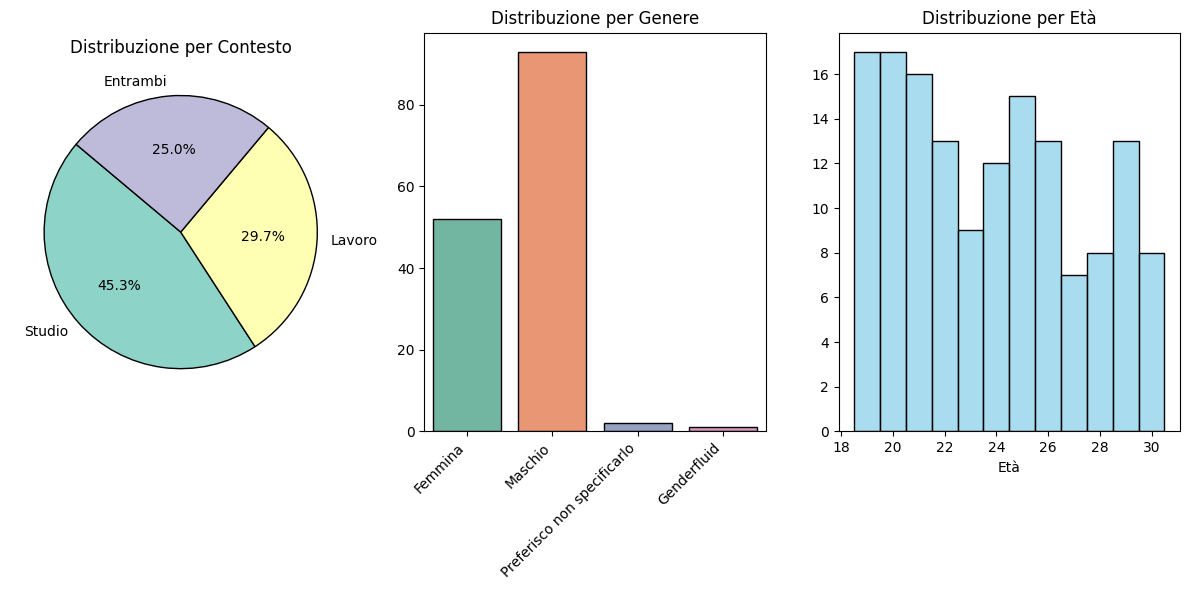

In [50]:
# subplot per contesto, per genere e per età
import matplotlib.pyplot as plt
import seaborn as sns           

plt.figure(figsize=(12, 6))
subplot1 = plt.subplot(1, 3, 1)
plt.pie(df_clean['contesto'].value_counts(), labels=df_clean['contesto'].value_counts().index, autopct='%1.1f%%', colors=sns.color_palette('Set3'), startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Distribuzione per Contesto') 
subplot2 = plt.subplot(1, 3, 2)
sns.countplot(data=df_clean, x='genere', palette='Set2', edgecolor='black', hue = None)
plt.title('Distribuzione per Genere')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=10)
subplot3 = plt.subplot(1, 3, 3)
sns.histplot(data=df_clean, x='età', bins=range(19, 32), kde=False, color='skyblue', edgecolor='black', alpha=0.7, stat='count', discrete=True, hue=None)
plt.title('Distribuzione per Età')
plt.xlabel('Età')
plt.ylabel('')
plt.tight_layout()

# salvataggio immagine
plt.savefig('../images/distribuzioni.png', dpi=130, bbox_inches='tight')
plt.show()